In [1]:
import torch
from torch.nn.functional import pad, avg_pool2d
from einops import rearrange


In [2]:
def pad_to_max_size(batch, patch_size):
    # Extract images and labels from the batch
    images, labels = zip(*batch)
    
    # Find the maximum height and width in the batch
    max_height = max(img.shape[1] for img in images)
    max_width = max(img.shape[2] for img in images)

    max_pixels = max_height * max_width
    
    padded_images = []
    patch_masks = []
    for img in images:
        _, h, w = img.shape
        pixel_row = rearrange(img, "b h w -> b (h w)")
        pixel_row = pixel_row

        print(pixel_row.shape)

        patch_mask = torch.ones(pixel_row.shape[1])

        # pad to max pixels
        pixel_row = pad(pixel_row, (0, max_pixels - pixel_row.shape[1]), value=0)
        patch_mask = pad(patch_mask, (0, max_pixels - patch_mask.shape[0]), value=0)

        print(f'pixel_row.shape: {pixel_row.shape}')
        print(f'patch_mask.shape: {patch_mask.shape}')
        
        # Downsample pixel-level mask to patch size
        # patch_mask = avg_pool2d(patch_mask, kernel_size=patch_size, stride=patch_size)
        # only keep every patch_size * patch_size pixels
        patch_mask = patch_mask[::patch_size*patch_size]
        patch_mask = (patch_mask > 0).int()  # Convert pooled mask to binary
        patch_masks.append(patch_mask)

        print(f'patch_mask.shape after pooling: {patch_mask.shape}')

        pixels = rearrange(pixel_row, "b (h w) -> b h w", h=max_height, w=max_width)
        print(f'pixels.shape: {pixels.shape}')
        padded_images.append(pixels)

    # Convert labels to a tensor
    labels = torch.tensor(labels)
    padded_images = torch.stack(padded_images)
    patch_masks = torch.stack(patch_masks)
    
    return padded_images, patch_masks, labels

torch.Size([3, 256])
pixel_row.shape: torch.Size([3, 400])
patch_mask.shape: torch.Size([400])
patch_mask.shape after pooling: torch.Size([100])
pixels.shape: torch.Size([3, 20, 20])
torch.Size([3, 120])
pixel_row.shape: torch.Size([3, 400])
patch_mask.shape: torch.Size([400])
patch_mask.shape after pooling: torch.Size([100])
pixels.shape: torch.Size([3, 20, 20])
torch.Size([3, 120])
pixel_row.shape: torch.Size([3, 400])
patch_mask.shape: torch.Size([400])
patch_mask.shape after pooling: torch.Size([100])
pixels.shape: torch.Size([3, 20, 20])


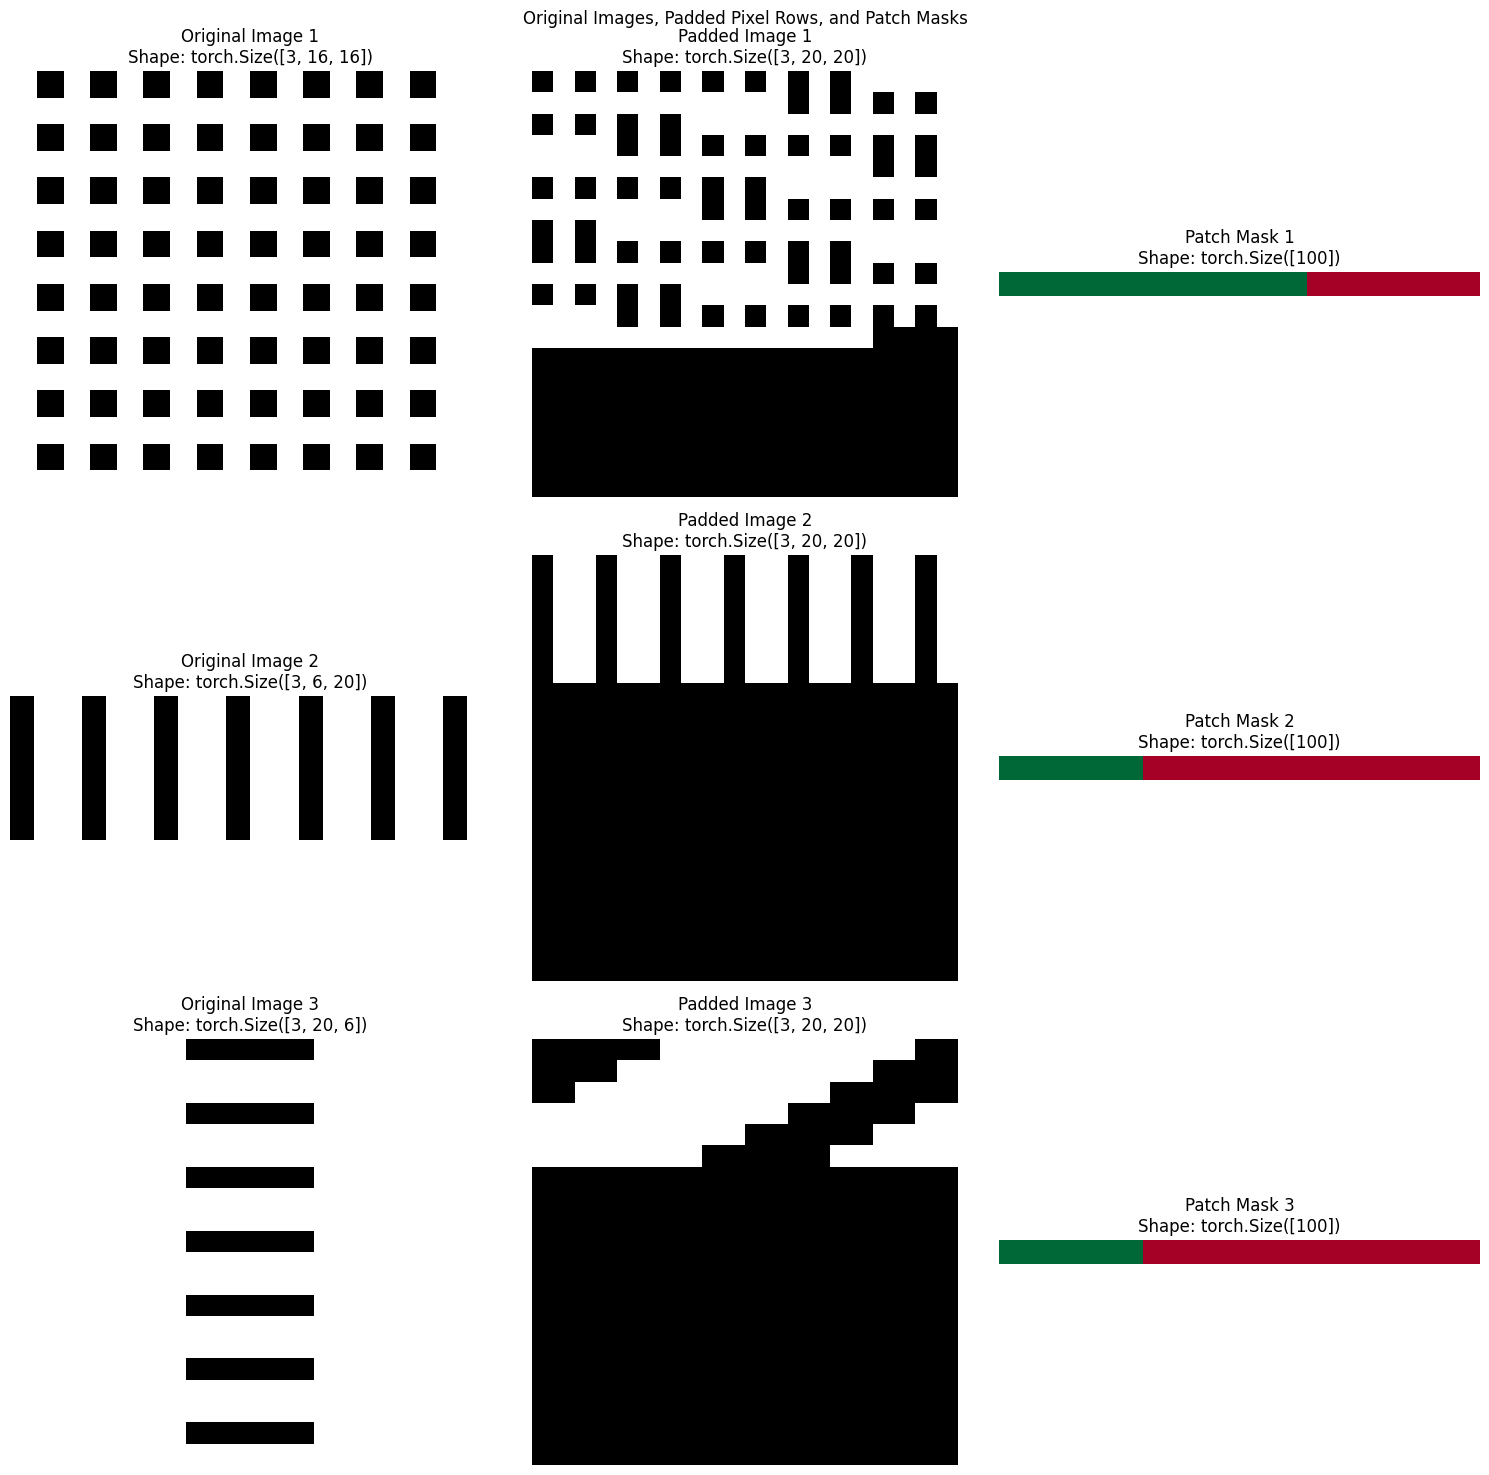

Padded images shape: torch.Size([3, 3, 20, 20])
Patch masks shape: torch.Size([3, 100])
Labels: tensor([0, 1, 2])


In [3]:
# Add this as a new cell
import torch
import matplotlib.pyplot as plt

# Create sample data with different sized images
def create_sample_batch():
    # Create 3 images of different sizes
    img1 = torch.ones(3, 16, 16)      # Square image
    img2 = torch.ones(3, 6, 20)      # Wide image
    img3 = torch.ones(3, 20, 6)      # Tall image
    
    # Add some pattern to easily distinguish the images
    img1[:, ::2, ::2] = 0  # Checkerboard pattern
    img2[:, :, ::3] = 0    # Vertical stripes
    img3[:, ::3, :] = 0    # Horizontal stripes
    
    # Create corresponding labels
    labels = [0, 1, 2]
    
    # Create batch
    batch = list(zip([img1, img2, img3], labels))
    return batch

# Test the padding function
batch = create_sample_batch()
patch_size = 2
padded_images, patch_masks, labels = pad_to_max_size(batch, patch_size)

# Visualize results
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Original Images, Padded Pixel Rows, and Patch Masks')

for i in range(3):
    # Original image
    axes[i,0].imshow(batch[i][0].permute(1,2,0))  # Permute for correct image display
    axes[i,0].set_title(f'Original Image {i+1}\nShape: {batch[i][0].shape}')
    axes[i,0].axis('off')
    
    # Padded pixel row (reshape to 2D for visualization)
    padded_row = padded_images[i].squeeze(0)  # Remove batch dimension
    axes[i,1].imshow(padded_row.permute(1,2,0))  # Permute for correct image display
    axes[i,1].set_title(f'Padded Image {i+1}\nShape: {padded_row.shape}')
    axes[i,1].axis('off')
    
    # Patch mask
    stacked_mask = torch.stack([patch_masks[i]]*5)
    axes[i,2].imshow(stacked_mask, cmap='RdYlGn')
    axes[i,2].set_title(f'Patch Mask {i+1}\nShape: {patch_masks[i].shape}')
    axes[i,2].axis('off')

plt.tight_layout()
plt.show()

print("Padded images shape:", padded_images.shape)
print("Patch masks shape:", patch_masks.shape)
print("Labels:", labels)